In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()

eq = load_earthquakes(min_mag=4.0)
print(f"EQ (M>=4.0): {len(eq)} zdarzeń, {eq.index.min()} .. {eq.index.max()}")


EQ (M>=4.0): 290945 zdarzeń, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000


In [2]:
def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


def full_d_scan(cr, eq, t0, P_days, m, dt_days, d_range):
    return {d: cosmoseismic_stat(cr, eq, t0, P_days, d, m, dt_days)["PCDF"] for d in d_range}


def circular_shift_eq(eq, rng):
    start, end = eq.index.min(), eq.index.max()
    span = end - start
    shift = pd.Timedelta(seconds=int(rng.uniform(0, span.total_seconds())))
    new_idx = (start + ((eq.index - start + shift) % span)).astype(eq.index.dtype)
    return pd.Series(eq.values, index=new_idx).sort_index()



t0 = pd.Timestamp("2013-11-14 07:00:00")  # ten sam t0 co dla Moskwy (walidacja artykułu)

In [3]:
# Loader dla Oulu (analogiczny do load_moscow). UWAGA: oulu_5min_data.csv
# ma jeden uszkodzony wiersz (linia 839815 w pliku) - pojedyncze pole z
# ~491k znaków "\x00\x00..." zamiast "datetime,value", w miejscu gdzie
# brakuje ok. 15 dni danych (1978-09-26 08:35 .. 1978-10-11 15:20).
# Bez tego jedno miejsce w pliku jest czyste (5.7M wierszy, sprawdzone
# przez awk pod kątem liczby pól i formatu daty). Parsujemy z
# errors="coerce" i odrzucamy niesparsowalne wiersze - decyzja Maćka:
# nie naprawiać pliku źródłowego, tylko pominąć wiersz przy wczytaniu.
OULU_PATH = "../data/oulu_5min_data.csv"

def load_oulu():
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    n_bad = df["datetime"].isna().sum()
    if n_bad:
        print(f"load_oulu: pominięto {n_bad} niesparsowalnych wierszy (uszkodzone dane)")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"]

cr_oulu_5min = load_oulu()
print(f"CR Oulu (5 min): {len(cr_oulu_5min)} pomiarów, {cr_oulu_5min.index.min()} .. {cr_oulu_5min.index.max()}")

# Resample do 6h (rozdzielczość Moskwy) - koszt full_d_scan/symulację skaluje
# się z liczbą wierszy cr, a przy 5 min (5.7M wierszy) MC dla n=1e4 kosztowałoby
# ~93 min (test kalibracyjny poniżej, przed resamplingiem, dał 559 ms/symulację).
# UWAGA: resampling zmienia samą wartość testu (best_pcdf), nie tylko szybkość -
# to inna analiza niż na surowych danych 5-min, porównywalna z Moskwą właśnie
# dlatego, że ma tę samą rozdzielczość czasową binowania.
cr_oulu = cr_oulu_5min.resample("6h").mean()
print(f"CR Oulu (6h, po resamplingu): {len(cr_oulu)} pomiarów "
      f"({len(cr_oulu_5min) / len(cr_oulu):.1f}x mniej niż 5 min)")

load_oulu: pominięto 1 niesparsowalnych wierszy (uszkodzone dane)
CR Oulu (5 min): 5720382 pomiarów, 1970-01-01 00:00:00 .. 2025-12-31 23:50:00
CR Oulu (6h, po resamplingu): 81816 pomiarów (69.9x mniej niż 5 min)


In [4]:
# Test kalibracyjny (po resamplingu Oulu do 6h - patrz komórka wyżej).
import sys, time
sys.path.insert(0, "..")
from mc_parallel import run_mc_parallel

t_scan = time.time()
sim_oulu = full_d_scan(cr_oulu, eq, t0, 1675, 4.0, 15, range(1, 31))
print(f"pełny full_d_scan (Oulu 6h, d=1..30): {time.time() - t_scan:.2f} s")
best_pcdf_oulu = min(sim_oulu.values())
print(f"best_pcdf(Oulu 6h, t0 jak dla Moskwy, bez shift) = {best_pcdf_oulu:.3e}")

n_calib = 20
t_mc = time.time()
mc_calib = run_mc_parallel(
    cr_oulu, eq, t0, 1675, 4.0, 15, n_calib,
    full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
    base_seed=42,
)
elapsed_calib = time.time() - t_mc
per_sim_oulu = elapsed_calib / n_calib
print(f"n_sims={n_calib} równolegle: {elapsed_calib:.1f} s ({per_sim_oulu*1000:.0f} ms/symulację)")
print(f"ekstrapolacja na n=1e4: {per_sim_oulu * 1e4 / 60:.1f} min")
print(f"ekstrapolacja na n=1e5: {per_sim_oulu * 1e5 / 60:.1f} min")

pełny full_d_scan (Oulu 6h, d=1..30): 0.43 s
best_pcdf(Oulu 6h, t0 jak dla Moskwy, bez shift) = 4.546e-05
n_sims=20 równolegle: 1.2 s (61 ms/symulację)
ekstrapolacja na n=1e4: 10.2 min
ekstrapolacja na n=1e5: 102.0 min


In [5]:
# Pełny Monte Carlo dla Oulu (6h, po resamplingu), n_sims=1e4 - przy 54 ms/symulację
# (test kalibracyjny wyżej) to ~9 min, więc w przeciwieństwie do Moskwy (n=1e5,
# ~87 min) nie ma potrzeby trzymać tego jako zakomentowany blok + wczytywanie
# z pliku - uruchamiamy wprost, ale i tak zapisujemy wynik do .npy (save_path),
# żeby dało się go później porównać (np. wpływ rozdzielczości czasowej binowania
# 5min vs 6h na wynik, bez konieczności ponownego liczenia).
n_sims = 10000
save_path = f"../results/mc_minima_oulu_n{n_sims}.npy"
t_start = time.time()
mc_minima_oulu = run_mc_parallel(
    cr_oulu, eq, t0, 1675, 4.0, 15, n_sims,
    full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
    base_seed=42, save_path=save_path,
)
elapsed = time.time() - t_start
print(f"n_sims={n_sims} w {elapsed:.1f} s ({elapsed / n_sims * 1000:.1f} ms/symulację)")
print(f"wynik zapisany do {save_path}")

p_global_oulu = (mc_minima_oulu <= best_pcdf_oulu).mean()
p_global_oulu_floor = max(p_global_oulu, 1 / n_sims)

n_sims=10000 w 523.6 s (52.4 ms/symulację)
wynik zapisany do mc_minima_oulu_n10000.npy


In [6]:
print(f"Monte Carlo Oulu (n_sims={n_sims}): p_global (empiryczne) = {p_global_oulu:.4f}")
print(f"  najbardziej ekstremalne minimum spod H0: {mc_minima_oulu.min():.3e}")
print(f"  mediana minimów spod H0: {np.median(mc_minima_oulu):.3e}")
print(f"  floor (bo 0/{n_sims}): p_global <= {p_global_oulu_floor:.4f} (~{norm.isf(p_global_oulu_floor):.2f} sigma)")

Monte Carlo Oulu (n_sims=10000): p_global (empiryczne) = 0.0119
  najbardziej ekstremalne minimum spod H0: 2.590e-07
  mediana minimów spod H0: 3.406e-02
  floor (bo 0/10000): p_global <= 0.0119 (~2.26 sigma)


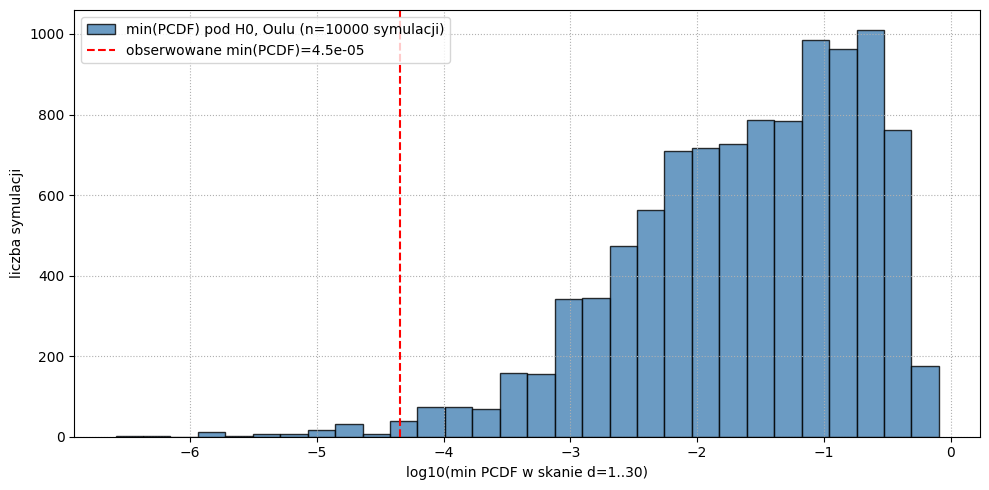

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10(mc_minima_oulu), bins=30, color="steelblue", edgecolor="black", alpha=0.8,
         label=f"min(PCDF) pod H0, Oulu (n={n_sims} symulacji)")
plt.axvline(np.log10(best_pcdf_oulu), color="red", ls="--",
            label=f"obserwowane min(PCDF)={best_pcdf_oulu:.1e}")
plt.xlabel("log10(min PCDF w skanie d=1..30)")
plt.ylabel("liczba symulacji")
plt.legend()
plt.grid(ls=":")
plt.tight_layout()
plt.show()